In [1]:
!pip install thop -q

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from thop import profile
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


**Data Splitting (90:10 Split & 10% Validation)**

In [2]:
train_dir = '/kaggle/input/datasets/soniasiraj/alzheimer-dataset-02/alzheimer/train'
test_dir = '/kaggle/input/datasets/soniasiraj/alzheimer-dataset-02/alzheimer/test'


classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
label_map = {cls: i for i, cls in enumerate(classes)}

all_paths = []
all_labels = []

def extract_data(directory):
    for cls in classes:
        folder_path = os.path.join(directory, cls)
        if os.path.exists(folder_path):
            for img in os.listdir(folder_path):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_paths.append(os.path.join(folder_path, img))
                    all_labels.append(label_map[cls])


extract_data(train_dir)
extract_data(test_dir)

# 1. First split: 90% Train, 10% Test
train_files, test_files, train_labels, test_labels = train_test_split(
    all_paths, all_labels, train_size=0.90, stratify=all_labels, random_state=42
)

# 2. Second split: 10% Validation from Train
t_files, v_files, t_labels, v_labels = train_test_split(
    train_files, train_labels, test_size=0.10, stratify=train_labels, random_state=42
)

class AlzheimerDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Resize and Normalize 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(AlzheimerDataset(t_files, t_labels, transform), batch_size=32, shuffle=True)
val_loader = DataLoader(AlzheimerDataset(v_files, v_labels, transform), batch_size=32, shuffle=False)
test_loader = DataLoader(AlzheimerDataset(test_files, test_labels, transform), batch_size=32, shuffle=False)

print(f"Classes Found: {classes}")
print(f"Total Images: {len(all_paths)} | Train: {len(t_files)} | Val: {len(v_files)} | Test: {len(test_files)}")

Classes Found: ['AD', 'CN', 'MCI']
Total Images: 5154 | Train: 4174 | Val: 464 | Test: 516


**Setup DenseNet121 & Calculate GFLOPs**

In [3]:
model = models.densenet121(weights='IMAGENET1K_V1')

model.classifier = nn.Linear(model.classifier.in_features, len(classes))
model = model.to(device)

# Calculate GFLOPs for a fixed input size of 224x224
dummy_in = torch.randn(1, 3, 224, 224).to(device)
macs, params = profile(model, inputs=(dummy_in, ), verbose=False)
gflops = (macs * 2) / 1e9

print(f"Model: DenseNet121 | Fixed Input Size: 224x224x3 | GFLOPs per inference: {gflops:.4f} GFLOPs")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 174MB/s]


Model: DenseNet121 | Fixed Input Size: 224x224x3 | GFLOPs per inference: 5.7920 GFLOPs


**Training Loop with Early Stopping & Wall-clock Time**

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses = []
val_losses = []

# Early stopping setup
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = model.state_dict()

start_train = time.time()
epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for imgs, labs in val_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            v_loss += criterion(model(imgs), labs).item()
    
    avg_val_loss = v_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # Check Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs. Restoring best weights.")
            break

# Load the best weights back to the model
model.load_state_dict(best_model_wts)

train_wall_time = time.time() - start_train
print(f"\nTotal Training Wall-clock Time: {train_wall_time:.2f} seconds")

Epoch [1/50] | Train Loss: 0.3634 | Val Loss: 0.1003
Epoch [2/50] | Train Loss: 0.0420 | Val Loss: 0.0296
Epoch [3/50] | Train Loss: 0.0181 | Val Loss: 0.0104
Epoch [4/50] | Train Loss: 0.0200 | Val Loss: 0.2861
Epoch [5/50] | Train Loss: 0.0475 | Val Loss: 0.0623
Epoch [6/50] | Train Loss: 0.0087 | Val Loss: 0.0056
Epoch [7/50] | Train Loss: 0.0041 | Val Loss: 0.0024
Epoch [8/50] | Train Loss: 0.0120 | Val Loss: 0.2463
Epoch [9/50] | Train Loss: 0.0177 | Val Loss: 0.0154
Epoch [10/50] | Train Loss: 0.0148 | Val Loss: 0.0106
Epoch [11/50] | Train Loss: 0.0086 | Val Loss: 0.0039
Epoch [12/50] | Train Loss: 0.0051 | Val Loss: 0.0169
Epoch [13/50] | Train Loss: 0.0080 | Val Loss: 0.0031
Epoch [14/50] | Train Loss: 0.0155 | Val Loss: 0.0327
Epoch [15/50] | Train Loss: 0.0195 | Val Loss: 0.1173
Epoch [16/50] | Train Loss: 0.0033 | Val Loss: 0.0005
Epoch [17/50] | Train Loss: 0.0006 | Val Loss: 0.0002
Epoch [18/50] | Train Loss: 0.0012 | Val Loss: 0.0008
Epoch [19/50] | Train Loss: 0.0035 | 

**Plot Training & Validation Learning Curves**

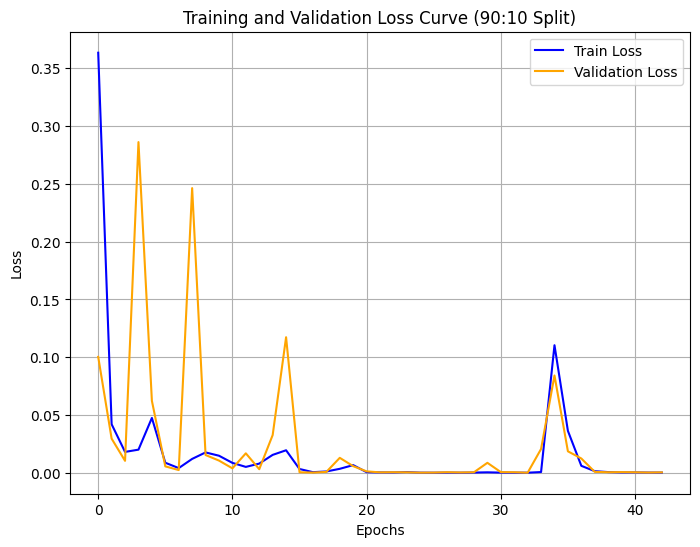

In [5]:
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve (90:10 Split)')
plt.legend()
plt.grid(True)
plt.show()

**Testing Inference, Metrics & Wall-clock Time**

In [6]:
model.eval()
y_true, y_pred, y_prob = [], [], []

print("Starting Inference...")
start_test = time.time()
with torch.no_grad():
    for imgs, labs in test_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        out = model(imgs)
        y_prob.extend(torch.softmax(out, dim=1).cpu().numpy())
        y_pred.extend(torch.argmax(out, dim=1).cpu().numpy())
        y_true.extend(labs.cpu().numpy())
test_wall_time = time.time() - start_test

# Calculate general metrics
acc = accuracy_score(y_true, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
auc_score = roc_auc_score(y_true, y_prob, multi_class='ovr')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Macro ROC-AUC: {auc_score:.4f}")
print(f"Testing Wall-clock Time: {test_wall_time:.2f} seconds")

Starting Inference...
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
Macro ROC-AUC: 1.0000
Testing Wall-clock Time: 6.92 seconds


**Per-Class Accuracy & Confusion Matrix**

Per-class Accuracy:
 - AD: 1.0000
 - CN: 1.0000
 - MCI: 1.0000


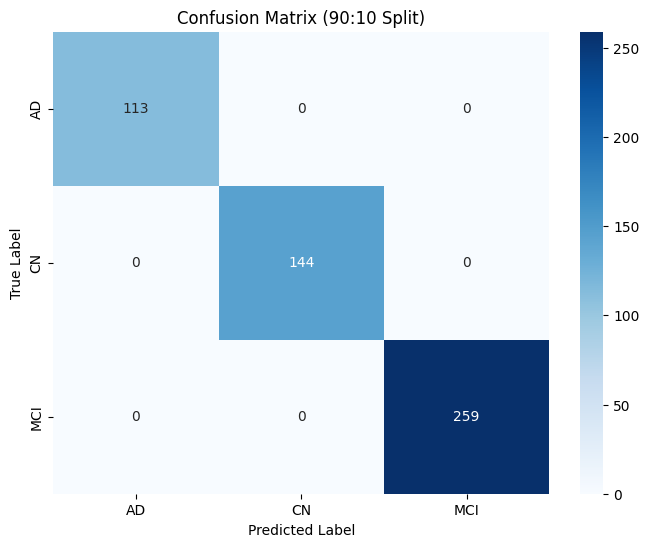

In [7]:
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print("Per-class Accuracy:")
for i, cls in enumerate(classes):
    print(f" - {cls}: {per_class_acc[i]:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix (90:10 Split)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**ROC Curves per class**

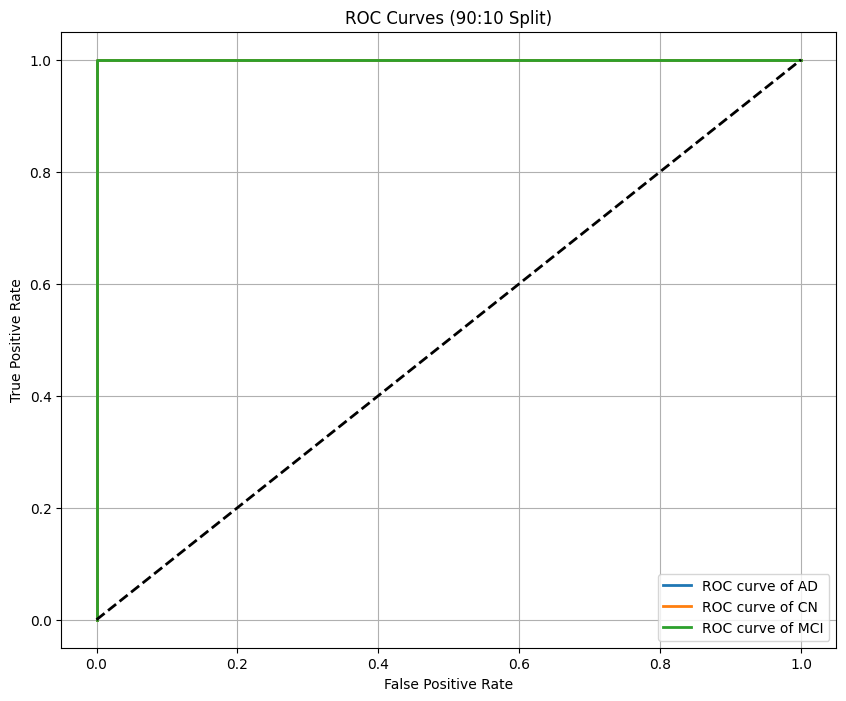

In [8]:
plt.figure(figsize=(10, 8))
y_prob_arr = np.array(y_prob)

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_true, y_prob_arr[:, i], pos_label=i)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of {classes[i]}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (90:10 Split)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()